MONTHLY DONOR ACTIVITY
last_donation_date
2007-01-01       1
2007-02-01       1
2007-03-01       2
2007-04-01       2
2007-05-01       3
              ... 
2024-08-01     999
2024-09-01     971
2024-10-01    1026
2024-11-01     946
2024-12-01     998
Name: donor_id, Length: 214, dtype: int64


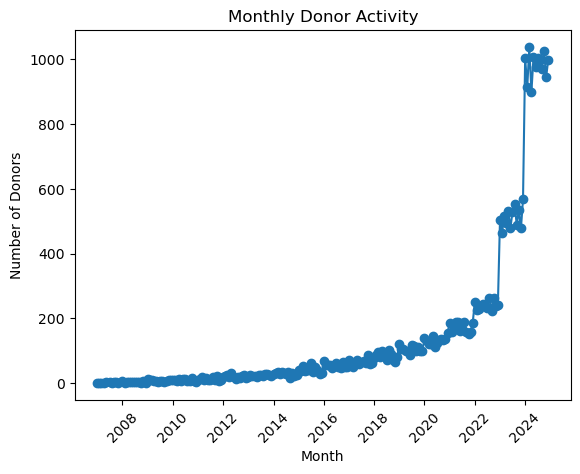


EXPONENTIAL SMOOTHING FORECAST
214    1011.431057
215    1027.901535
216    1044.372014
217    1060.842492
218    1077.312970
219    1093.783449
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_date


ARIMA FORECAST
214    977.944009
215    989.170617
216    982.886374
217    986.404062
218    984.434989
219    985.537204
Name: predicted_mean, dtype: float64


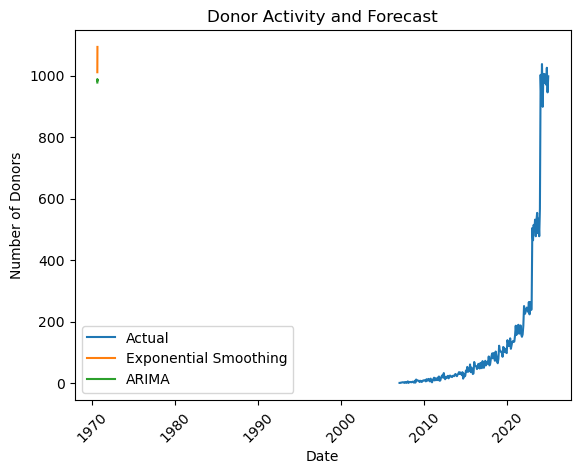

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Load Dataset
df = pd.read_csv("blood_donation_registry_ml_ready.csv")

# Convert date
df["last_donation_date"] = pd.to_datetime(df["last_donation_date"])

# Monthly donor activity
monthly_data = df.groupby(
    df["last_donation_date"].dt.to_period("M")
)["donor_id"].nunique()

monthly_data.index = monthly_data.index.to_timestamp()

print("MONTHLY DONOR ACTIVITY")
print(monthly_data)

# Line Chart
plt.plot(monthly_data.index, monthly_data.values, marker="o")
plt.title("Monthly Donor Activity")
plt.xlabel("Month")
plt.ylabel("Number of Donors")
plt.xticks(rotation=45)
plt.show()


# Exponential Smoothing
model_es = ExponentialSmoothing(
    monthly_data,
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

forecast_es = fit_es.forecast(6)

print("\nEXPONENTIAL SMOOTHING FORECAST")
print(forecast_es)


# ARIMA
model_arima = ARIMA(
    monthly_data,
    order=(1, 1, 1)
)

fit_arima = model_arima.fit()

forecast_arima = fit_arima.forecast(6)

print("\nARIMA FORECAST")
print(forecast_arima)


# Plot Forecasts
plt.plot(monthly_data.index, monthly_data.values, label="Actual")

plt.plot(
    forecast_es.index,
    forecast_es.values,
    label="Exponential Smoothing"
)

plt.plot(
    forecast_arima.index,
    forecast_arima.values,
    label="ARIMA"
)

plt.title("Donor Activity and Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Donors")
plt.legend()
plt.xticks(rotation=45)
plt.show()